<a href="https://colab.research.google.com/github/ivanlukianets/Deep-Learning-Assignment-1/blob/main/Adversarial_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [5]:
# Download latest version
path = kagglehub.competition_download('home-credit-default-risk')

print("Path to competition files:", path)

100%|██████████| 688M/688M [00:07<00:00, 94.0MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/home-credit-default-risk


In [6]:
! ls /root/.cache/kagglehub/competitions/home-credit-default-risk

application_test.csv	 HomeCredit_columns_description.csv
application_train.csv	 installments_payments.csv
bureau_balance.csv	 POS_CASH_balance.csv
bureau.csv		 previous_application.csv
credit_card_balance.csv  sample_submission.csv


In [7]:
import numpy as np
import pandas as pd
from pathlib import Path

DATA_PATH = Path('./data')

# Load raw data
df_train = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/application_train.csv")
df_test  = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/application_test.csv")
bureau   = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/bureau.csv")
pos      = pd.read_csv("/root/.cache/kagglehub/competitions/home-credit-default-risk/POS_CASH_balance.csv")

# ============================================================
# BUREAU FEATURES
# ============================================================
active    = bureau['CREDIT_ACTIVE'].eq('Active')
card_limit = bureau['AMT_CREDIT_SUM_LIMIT'].where(
    bureau['CREDIT_TYPE'].eq('Credit card') & bureau['AMT_CREDIT_SUM_LIMIT'].gt(0)
)

bureau = bureau.assign(
    IS_ACTIVE        = active,
    DAYS_SINCE_OPENED= -bureau['DAYS_CREDIT'],
    OPENED_LAST_YEAR = bureau['DAYS_CREDIT'].ge(-365),
    ACTIVE_DEBT      = bureau['AMT_CREDIT_SUM_DEBT'].clip(lower=0).where(active, 0),
    ACTIVE_CREDIT    = bureau['AMT_CREDIT_SUM'].where(active, 0),
    CARD_UTILIZATION = bureau['AMT_CREDIT_SUM_DEBT'].clip(lower=0) / card_limit,
    CLOSED_EARLY     = bureau['DAYS_ENDDATE_FACT'].lt(bureau['DAYS_CREDIT_ENDDATE']),
)

bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_CARD_UTILIZATION     = ('CARD_UTILIZATION', 'mean'),
    BUREAU_DAYS_SINCE_LAST_LOAN = ('DAYS_SINCE_OPENED', 'min'),
    BUREAU_N_LOANS_LAST_YEAR    = ('OPENED_LAST_YEAR', 'sum'),
    BUREAU_N_ACTIVE             = ('IS_ACTIVE', 'sum'),
    BUREAU_ACTIVE_SHARE         = ('IS_ACTIVE', 'mean'),
    BUREAU_EARLY_CLOSE_SHARE    = ('CLOSED_EARLY', 'mean'),
    BUREAU_DAYS_SINCE_FIRST_LOAN= ('DAYS_SINCE_OPENED', 'max'),
    ACTIVE_DEBT                 = ('ACTIVE_DEBT', 'sum'),
    ACTIVE_CREDIT               = ('ACTIVE_CREDIT', 'sum'),
)

def add_bureau_features(frame):
    frame = frame.merge(bureau_agg, left_on='SK_ID_CURR', right_index=True, how='left')
    frame['HAS_BUREAU']          = frame['BUREAU_N_ACTIVE'].notna().astype(int)
    frame['BUREAU_DEBT_TO_INCOME']  = frame['ACTIVE_DEBT'] / frame['AMT_INCOME_TOTAL']
    frame['BUREAU_DEBT_STILL_OWED'] = frame['ACTIVE_DEBT'] / frame['ACTIVE_CREDIT'].replace(0, np.nan)
    return frame.drop(columns=['ACTIVE_DEBT', 'ACTIVE_CREDIT'])

df_train = add_bureau_features(df_train)
df_test  = add_bureau_features(df_test)

bureau_features = [
    'HAS_BUREAU', 'BUREAU_CARD_UTILIZATION',
    'BUREAU_DAYS_SINCE_LAST_LOAN', 'BUREAU_N_LOANS_LAST_YEAR',
    'BUREAU_N_ACTIVE', 'BUREAU_ACTIVE_SHARE', 'BUREAU_DEBT_TO_INCOME',
    'BUREAU_DEBT_STILL_OWED', 'BUREAU_EARLY_CLOSE_SHARE',
    'BUREAU_DAYS_SINCE_FIRST_LOAN',
]
print(f'Bureau features added: {len(bureau_features)}')

Bureau features added: 10


In [8]:

# ============================================================
# POS CASH FEATURES
# ============================================================
pos = pos.assign(IS_LATE=pos['SK_DPD_DEF'].gt(0))

pos_agg = pos.groupby('SK_ID_CURR').agg(
    POS_N_LOANS  = ('SK_ID_PREV', 'nunique'),
    POS_HIST_LEN = ('MONTHS_BALANCE', lambda months: -months.min()),
    POS_DPD_SHARE= ('IS_LATE', 'mean'),
)

pos_agg['POS_MONTHS_SINCE_DPD'] = \
    -pos[pos['IS_LATE']].groupby('SK_ID_CURR')['MONTHS_BALANCE'].max()

last_month  = pos.sort_values('MONTHS_BALANCE').groupby('SK_ID_PREV').tail(1)
active_last = last_month[
    last_month['NAME_CONTRACT_STATUS'].eq('Active') &
    last_month['CNT_INSTALMENT'].gt(0)
]
pos_agg['POS_PROGRESS_LEFT'] = (
    (active_last['CNT_INSTALMENT_FUTURE'] / active_last['CNT_INSTALMENT'])
    .groupby(active_last['SK_ID_CURR']).mean()
)

def add_pos_features(frame):
    frame = frame.merge(pos_agg, left_on='SK_ID_CURR', right_index=True, how='left')
    frame['HAS_POS']             = frame['POS_N_LOANS'].notna().astype(int)
    frame['POS_MONTHS_SINCE_DPD']= frame['POS_MONTHS_SINCE_DPD'].fillna(999)
    return frame

df_train = add_pos_features(df_train)
df_test  = add_pos_features(df_test)

pos_features = [
    'HAS_POS', 'POS_N_LOANS', 'POS_HIST_LEN',
    'POS_DPD_SHARE', 'POS_MONTHS_SINCE_DPD', 'POS_PROGRESS_LEFT',
]
print(f'POS features added: {len(pos_features)}')

POS features added: 6


In [9]:
# These column groups are defined for you
contact_flags   = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                   'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']
document_flags  = [f'FLAG_DOCUMENT_{n}' for n in range(2, 22)]
rating_columns  = ['REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT']
social_observed = [f'OBS_{d}_CNT_SOCIAL_CIRCLE' for d in (30, 60)]
social_defaulted= [f'DEF_{d}_CNT_SOCIAL_CIRCLE' for d in (30, 60)]

def make_features(frame):
    frame = frame.copy()

    # HINT 1: Average of contact flags → CONTACT_FLAG_SCORE
    frame['CONTACT_FLAG_SCORE'] = frame[contact_flags].sum(axis=1) / len(contact_flags)

    # HINT 2: Average of document flags → DOCUMENT_FLAG_SCORE
    frame['DOCUMENT_FLAG_SCORE'] = frame[document_flags].sum(axis=1) / len(document_flags)

    # HINT 3: Weighted region rating (0.7 city + 0.3 region)
    city   = frame['REGION_RATING_CLIENT_W_CITY'].replace(-1, np.nan)
    region = frame['REGION_RATING_CLIENT'].replace(-1, np.nan)
    frame['REGION_RATING_SCORE'] = (0.7 * city + 0.3 * region).fillna(city).fillna(region)

    # HINT 4: Social default rate for 30 and 60 days
    for days in (30, 60):
        observed  = frame[f'OBS_{days}_CNT_SOCIAL_CIRCLE']
        defaulted = frame[f'DEF_{days}_CNT_SOCIAL_CIRCLE']
        # Rate = defaulted/observed, 0 if no observed
        frame[f'SOCIAL_DEFAULT_RATE_{days}'] = defaulted.div(observed).where(observed.ne(0), 0)

    # HINT 5: Convert DAYS_BIRTH to age in years
    frame['AGE_YEARS'] = -frame['DAYS_BIRTH'] / 365.25

    # HINT 6: Age bins (20 to 70, 10 equal bins)
    frame['AGE_BIN'] = pd.cut(frame['AGE_YEARS'], bins=np.linspace(20, 70, num=11), labels=False, include_lowest=True)

    # HINT 7: Employment anomaly flag (365243 = anomaly)
    frame['DAYS_EMPLOYED_ANOM'] = frame['DAYS_EMPLOYED'].eq(365243).astype(int)

    # HINT 8: Convert DAYS_EMPLOYED to years (replace anomaly with NaN)
    frame['EMPLOYED_YEARS'] = -frame['DAYS_EMPLOYED'].replace(365243, np.nan) / 365.25

    # HINT 9: Convert remaining DAYS_ columns to years
    frame['YEARS_SINCE_REGISTRATION'] = -frame['DAYS_REGISTRATION'] / 365.25
    frame['YEARS_SINCE_ID_PUBLISH']   = -frame['DAYS_ID_PUBLISH'] / 365.25
    frame['YEARS_SINCE_PHONE_CHANGE'] = -frame['DAYS_LAST_PHONE_CHANGE'] / 365.25

    # HINT 10: Drop original columns we no longer need
    return frame.drop(columns=[
        'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE'
    ] + contact_flags + document_flags + rating_columns + social_defaulted)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_raw = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_POPULATION_RELATIVE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'OWN_CAR_AGE',
]
categorical = [
    'NAME_CONTRACT_TYPE', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'ORGANIZATION_TYPE',
]

# Numeric features after make_features (no more DAYS_ columns)
numeric = [c for c in numeric_raw
           if not c.startswith('DAYS_') and c != 'OWN_CAR_AGE'] + [
    'AGE_YEARS', 'AGE_BIN', 'EMPLOYED_YEARS', 'DAYS_EMPLOYED_ANOM',
    'YEARS_SINCE_REGISTRATION', 'YEARS_SINCE_ID_PUBLISH',
    'YEARS_SINCE_PHONE_CHANGE', 'CONTACT_FLAG_SCORE',
    'DOCUMENT_FLAG_SCORE', 'REGION_RATING_SCORE',
    *social_observed, 'SOCIAL_DEFAULT_RATE_30', 'SOCIAL_DEFAULT_RATE_60',
]

preprocess = ColumnTransformer(
    transformers=[
        # HINT: numeric → median imputation
        ('numeric',     SimpleImputer(strategy="median"),                          numeric),
        # HINT: OWN_CAR_AGE → median + missing indicator
        ('car_age',     SimpleImputer(strategy="median", add_indicator=True),       ['OWN_CAR_AGE']),
        # HINT: bureau → fill with 0 (no bureau = 0)
        ('bureau',      SimpleImputer(strategy="constant", fill_value=0),          bureau_features),
        # HINT: pos → fill with 0
        ('pos',         SimpleImputer(strategy="constant", fill_value=0),          pos_features),
        # HINT: categorical → impute most_frequent + OneHotEncode
        ('categorical', Pipeline([
            ('impute', SimpleImputer(strategy="most_frequent")),
            ('onehot', OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]),                                                                    categorical),
    ],
    sparse_threshold=0.0,
)

In [11]:
# ============================================================
# Define all column groups
# ============================================================
contact_flags = [
    'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
    'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL'
]
document_flags  = [f'FLAG_DOCUMENT_{n}' for n in range(2, 22)]
rating_columns  = ['REGION_RATING_CLIENT_W_CITY', 'REGION_RATING_CLIENT']
social_observed = [f'OBS_{d}_CNT_SOCIAL_CIRCLE' for d in (30, 60)]
social_defaulted= [f'DEF_{d}_CNT_SOCIAL_CIRCLE' for d in (30, 60)]

numeric_raw = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_POPULATION_RELATIVE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 'OWN_CAR_AGE',
]
categorical = [
    'NAME_CONTRACT_TYPE', 'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'ORGANIZATION_TYPE',
]

# ============================================================
# IMPORTANT: feature_columns must be defined BEFORE Cell 5!
# ============================================================
feature_columns = (
    numeric_raw       +
    contact_flags     +
    document_flags    +
    rating_columns    +
    social_observed   +
    social_defaulted  +
    bureau_features   +  # From Cell 1
    pos_features      +  # From Cell 2
    categorical
)

print(f"Total feature columns: {len(feature_columns)}")
print(f"Missing from df_train: {[c for c in feature_columns if c not in df_train.columns]}")
print(f"Missing from df_test:  {[c for c in feature_columns if c not in df_test.columns]}")

Total feature columns: 70
Missing from df_train: []
Missing from df_test:  []


In [12]:
X_train_raw = df_train[feature_columns].copy()
X_test_raw  = df_test[feature_columns].copy()
y_train     = df_train['TARGET'].copy()

X_train_featured = make_features(X_train_raw)
X_test_featured  = make_features(X_test_raw)

print(f"After make_features train shape: {X_train_featured.shape}")

X_train_processed = preprocess.fit_transform(X_train_featured)
X_test_processed  = preprocess.transform(X_test_featured)

print(f"Processed train shape: {X_train_processed.shape}")
print(f"Processed test shape:  {X_test_processed.shape}")

feature_names = preprocess.get_feature_names_out()
print(f"Feature names count: {len(feature_names)}")

# ✅ Now convert to DataFrame
df_train_processed = pd.DataFrame(X_train_processed, columns=feature_names)
df_test_processed  = pd.DataFrame(X_test_processed,  columns=feature_names)
df_train_processed['TARGET'] = y_train.values

print(f"\n✅ df_train_processed: {df_train_processed.shape}")
print(f"✅ df_test_processed:  {df_test_processed.shape}")

After make_features train shape: (307511, 47)
Processed train shape: (307511, 123)
Processed test shape:  (48744, 123)
Feature names count: 123

✅ df_train_processed: (307511, 124)
✅ df_test_processed:  (48744, 123)


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


train_adv = df_train_processed.copy()
test_adv = df_test_processed.copy()

train_adv['is_test'] = 0
test_adv['is_test'] = 1
train_adv = train_adv.drop(columns=['TARGET'])
df_adv = pd.concat([train_adv, test_adv], axis=0, ignore_index=True)


X_adv = df_adv.drop(columns=['is_test'])
y_adv = df_adv['is_test']

In [20]:
X_adv_train, X_adv_val, y_adv_train, y_adv_val = train_test_split(
    X_adv, y_adv,
    test_size=0.33,
    stratify=y_adv,
    random_state=42
)

adv_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

adv_model.fit(X_adv_train, y_adv_train)
adv_preds = adv_model.predict_proba(X_adv_val)[:, 1]
auc_score = roc_auc_score(y_adv_val, adv_preds)

print(f"Adversarial Validation ROC AUC: {auc_score:.4f}")

Adversarial Validation ROC AUC: 0.7783


Top 10 features separating Train from Test:
                                       Feature  Importance
42  categorical__NAME_CONTRACT_TYPE_Cash loans    0.188280
2                         numeric__AMT_ANNUITY    0.083078
4                        numeric__EXT_SOURCE_1    0.071709
1                          numeric__AMT_CREDIT    0.070127
18                numeric__DOCUMENT_FLAG_SCORE    0.057546
15             numeric__YEARS_SINCE_ID_PUBLISH    0.046942
28         bureau__BUREAU_DAYS_SINCE_LAST_LOAN    0.044033
3                     numeric__AMT_GOODS_PRICE    0.040847
38                           pos__POS_HIST_LEN    0.036593
16           numeric__YEARS_SINCE_PHONE_CHANGE    0.027729


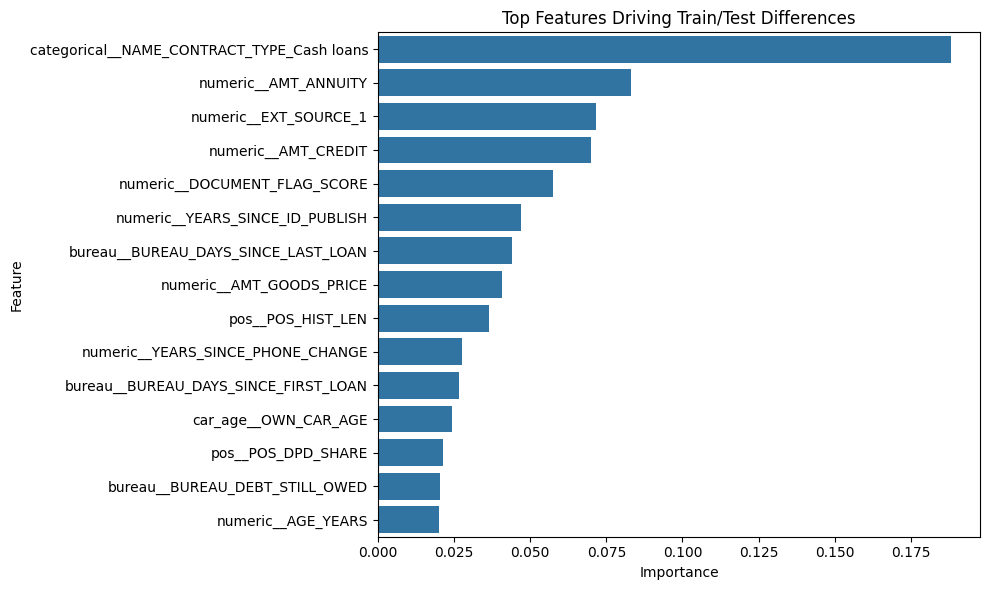

In [21]:
# Get feature importances from the adversarial model
importance_df = pd.DataFrame({
    'Feature': X_adv.columns,
    'Importance': adv_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Top 10 features separating Train from Test:")
print(importance_df.head(10))

# Plot the top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title('Top Features Driving Train/Test Differences')
plt.tight_layout()
plt.show()

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns


train_adv = df_train_processed.copy()
test_adv = df_test_processed.copy()

train_adv['is_test'] = 0
test_adv['is_test'] = 1
train_adv = train_adv.drop(columns=['TARGET'])
train_adv = train_adv.drop(columns=['categorical__NAME_CONTRACT_TYPE_Cash loans'])
test_adv = test_adv.drop(columns=['categorical__NAME_CONTRACT_TYPE_Cash loans'])

df_adv = pd.concat([train_adv, test_adv], axis=0, ignore_index=True)


X_adv = df_adv.drop(columns=['is_test'])
y_adv = df_adv['is_test']

In [27]:
X_adv_train, X_adv_val, y_adv_train, y_adv_val = train_test_split(
    X_adv, y_adv,
    test_size=0.33,
    stratify=y_adv,
    random_state=42
)

adv_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

adv_model.fit(X_adv_train, y_adv_train)
adv_preds = adv_model.predict_proba(X_adv_val)[:, 1]
auc_score = roc_auc_score(y_adv_val, adv_preds)

print(f"Adversarial Validation ROC AUC: {auc_score:.4f}")

Adversarial Validation ROC AUC: 0.7783
